# Classification (Multi-Class): Iris Dataset

In [9]:
# First, we import our libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC, SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

In [2]:
# Load the Dataset
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size = 0.2, random_state = 1 )

In [4]:
X[:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

In [5]:
len(X_train), len(y_train), len(X_test), len(y_test)

(120, 120, 30, 30)

In [6]:
# Train a Classifier. Let's use a Logistic Regression
from sklearn.linear_model import LogisticRegression
clf_model = LogisticRegression(max_iter=200)
clf_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [7]:
# Evaluate the Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred = clf_model.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9666666666666667


In [9]:
print(y_pred)
print(y_test)

[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]
[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2]


In [10]:
print("\nClassification Report:\n", classification_report(y_test,y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [11]:
# For Class A: Precision_A = TruePositives_A / (TruePositives_A + FalsePo
# For Class B: Precision_B = TruePositives_B / (TruePositives_B + FalsePo
# For Class C: Precision_C = TruePositives_C / (TruePositives_C + FalsePo
# for our problem, if we should calculate by hand:
print(6/(1+0))
print((6/7)*100)

6.0
85.71428571428571


In [12]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


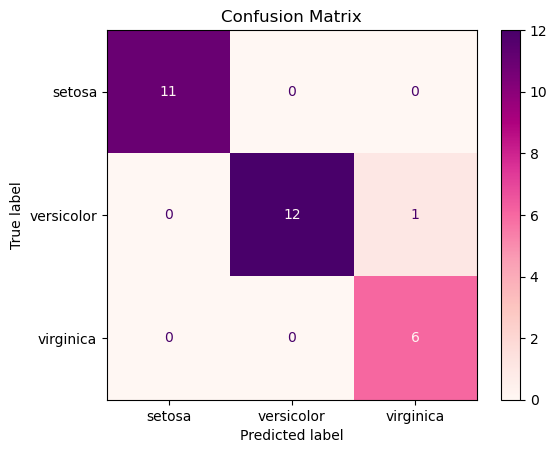

In [14]:
import matplotlib.pyplot as plt
cm_display = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=iris.target_names)
cm_display.plot(cmap=plt.cm.RdPu)
plt.title('Confusion Matrix')
# plt.colorbar()
plt.show()

In [15]:
len(X_test)

30

In [16]:
print(y_pred)
print(y_test)

[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]
[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2]


In [17]:
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):
 sample = [[sepal_length, sepal_width, petal_length, petal_width]]

 # Predict
 pred = clf_model.predict(sample)[0]
 species = iris.target_names
 prediction = f'The specie of flower is {species[pred]}'

 return prediction


In [18]:
print(predict_flower(5.1, 3.5, 1.4, 0.2))

The specie of flower is setosa


In [19]:
print(predict_flower(6.0, 3.0, 4.8, 1.8))

The specie of flower is virginica


In [20]:
clf_model.predict([[5.1, 3.5, 1.4, 0.2]])

array([0])

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size = 0.2, random_state = 1 )

In [28]:
pipeline = Pipeline([
    ("Scaler", StandardScaler()),
    ('model', LogisticRegression())
])
pipeline.fit(X_train, y_train)

,steps,"[('Scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [41]:
y_pred = pipeline.predict(X_test)
y_accuracy = accuracy_score(
    y_pred,
    y_test
)
print("Accuracy:", y_accuracy)
# mse = mean_squared_error(y_test, y_pred)
# rse = r2_score(y_test, y_pred)
# print(f'mse: {mse:.2f}')
# print(f'rse {rse:.2f}')

Accuracy: 0.9666666666666667


In [35]:
def predict_iris_flower(sepal_length, sepal_width, petal_length, petal_width):
 sample = [[sepal_length, sepal_width, petal_length, petal_width]]
 pred = pipeline.predict(sample)[0]
 prediction = f"selected iris flower: {iris.target_names[pred]}"
 return prediction

In [36]:
print(predict_iris_flower(5.1, 3.5, 1.4, 0.2))

selected iris flower: setosa


In [39]:
print(predict_iris_flower(6.0, 3.5, 4.8, 1.8))

selected iris flower: virginica


In [27]:
print(pipeline)

Pipeline(steps=[('Scaler', StandardScaler()), ('model', LinearRegression())])


In [40]:
print(y_test)
print(y_pred)

[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2]
[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]
